<a href="https://colab.research.google.com/github/Nikhil5566/EDA-Repo/blob/main/Amazon_Fashion_Products_Dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()
import warnings
warnings.filterwarnings('ignore')

In [3]:

# Installing Kaggle API
!pip install -q kaggle

# Uploading kaggle.json
from google.colab import files
files.upload()

# Moving kaggle.json to ~/.kaggle/
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# Downloading the dataset using Kaggle API
!kaggle datasets download -d poorveshchaudhari/amazon-fashion-products

# Unziping the downloaded file
!unzip amazon-fashion-products.zip

Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/poorveshchaudhari/amazon-fashion-products
License(s): apache-2.0
  0% 0.00/682k [00:00<?, ?B/s]
100% 682k/682k [00:00<00:00, 882MB/s]
Archive:  amazon-fashion-products.zip
  inflating: products.csv            


In [4]:
df = pd.read_csv('products.csv')
df.head(11)

,product_id,brand,title,price,category,rating,image_url,product_url
0,B08YRWN3WB,JANSPORT,Big Student Large laptop backpack Black EK0A5B...,189.00,New season,4.7,https://m.media-amazon.com/images/I/51y2EF0OmO...,https://www.amazon.ae/dp/B08YRWN3WB
1,B08YRXFZZM,JANSPORT,Superbreak Day Pack,119.00,New season,4.6,https://m.media-amazon.com/images/I/51yvvQUs3S...,https://www.amazon.ae/dp/B08YRXFZZM
2,B09Q2PQ7ZB,BAODINI,Mini Travel Umbrella With Case Small Compact U...,17.79,New season,4.2,https://m.media-amazon.com/images/I/71WbrZPbnG...,https://www.amazon.ae/dp/B09Q2PQ7ZB
3,B001BEAWXY,Calvin Klein,Men's Cotton Classics 3-Pack Boxer Brief,119.00,New season,4.2,https://m.media-amazon.com/images/I/716vzeqa7Z...,https://www.amazon.ae/dp/B001BEAWXY
4,B09FM5PMN3,JANSPORT,Unisex Kids Bag Backpack,179.00,New season,4.4,https://m.media-amazon.com/images/I/51XASBuqjr...,https://www.amazon.ae/dp/B09FM5PMN3
5,B08YRVSZLJ,JANSPORT,Superbreak Backpack,129.00,New season,4.6,https://m.media-amazon.com/images/I/51kw4Xtzuy...,https://www.amazon.ae/dp/B08YRVSZLJ
6,B0BY12QTS5,yeuG,"Non Slip Pilates Socks with Grips for Women, G...",19.00,New season,4.6,https://m.media-amazon.com/images/I/71g1ZrrOk9...,https://www.amazon.ae/dp/B0BY12QTS
7,B09N2PJXRZ,adidas,unisex Classic 3-Stripes Backpack BACKPACK,77.00,New season,4.5,https://m.media-amazon.com/images/I/81Beonq+r1...,https://www.amazon.ae/dp/B09N2PJXRZ
8,B08GS7DWS1,Tommy Hilfiger,"THEO Men Watch, Analog",209.60,New season,4.4,https://m.media-amazon.com/images/I/614YUufLpw...,https://www.amazon.ae/dp/B08GS7DWS
9,B08YRXDNB9,JANSPORT,Unisex Basic Accessory Pouch Pencil case,NaN,New season,4.6,https://m.media-amazon.com/images/I/51fQ6zVFiU...,https://www.amazon.ae/dp/B08YRXDNB9


In [5]:
df.tail(11)

,product_id,brand,title,price,category,rating,image_url,product_url
13145,B0FCX5KGHW,AZFVBQL,Zodiac Necklace for Men Stainless Steels 12 Co...,61.63,Accessories,4.5,https://m.media-amazon.com/images/I/71RkjINuSM...,https://www.amazon.ae/dp/B0FCX5KGHW
13146,B0D1YMJW1X,DuoDiner,Initial Letter Pendant Necklace for Men Boys D...,65.48,Accessories,4.7,https://m.media-amazon.com/images/I/81v8i4PEYo...,https://www.amazon.ae/dp/B0D1YMJW1X
13147,B07CHHVY7P,TI-EDC,"Pure Titanium Bead Ball Chain Necklace, Jewelr...",77.01,Accessories,4.5,https://m.media-amazon.com/images/I/81lcuDulOT...,https://www.amazon.ae/dp/B07CHHVY7P
13148,B09CLFLCGC,Falcon Jewelry,Real Arizona Turquoise Gemstone Ring - Sterlin...,618.08,Accessories,NaN,https://m.media-amazon.com/images/I/61N2n8fLl8...,https://www.amazon.ae/dp/B09CLFLCGC
13149,B0CS99FMGZ,J.Endéar,Horseshoe Nautical Bracelet | Handmade Paracor...,111.02,Accessories,4.6,https://m.media-amazon.com/images/I/71-9y2I6Hk...,https://www.amazon.ae/dp/B0CS99FMGZ
13150,B01M0J414M,LIEBLICH,Huggie Stud Earrings Black Small Hoop Stainles...,43.08,Accessories,4.5,https://m.media-amazon.com/images/I/61C-XNteze...,https://www.amazon.ae/dp/B01M0J414M
13151,B000QULS3M,Sabona,"Mens’ Stainless Steel Magnetic Bracelet, Sport...",193.82,Accessories,4.2,https://m.media-amazon.com/images/I/51+6l3CD4E...,https://www.amazon.ae/dp/B000QULS3M
13152,B07VYZ6PFH,U7,925 Sterling Silver 18K Gold Plated Oval Mirac...,206.00,Accessories,4.7,https://m.media-amazon.com/images/I/71uutEyhD4...,https://www.amazon.ae/dp/B07VYZ6PFH
13153,B09BK5CNC3,Tommy Hilfiger,ROUND BRAIDED BRACELET MENS LEATHER BRACELET -...,110.00,Accessories,4.5,https://m.media-amazon.com/images/I/71CbQ4Sixb...,https://www.amazon.ae/dp/B09BK5CNC3
13154,B088ZVMFCK,ThunderFit,"Silicone Wedding Rings for Men, 2 Layers Round...",69.74,Accessories,4.5,https://m.media-amazon.com/images/I/818yA0FJ9R...,https://www.amazon.ae/dp/B088ZVMFCK


In [6]:
df.shape

(13156, 8)

In [7]:
df.columns

Index(['product_id', 'brand', 'title', 'price', 'category', 'rating',
       'image_url', 'product_url'],
      dtype='object')

In [8]:
df.dtypes

,0
product_id,object
brand,object
title,object
price,float64
category,object
rating,float64
image_url,object
product_url,object


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13156 entries, 0 to 13155
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   product_id   13156 non-null  object 
 1   brand        13155 non-null  object 
 2   title        13155 non-null  object 
 3   price        12963 non-null  float64
 4   category     13156 non-null  object 
 5   rating       12273 non-null  float64
 6   image_url    13156 non-null  object 
 7   product_url  13156 non-null  object 
dtypes: float64(2), object(6)
memory usage: 822.4+ KB


In [10]:
df.describe(include = 'all')

,product_id,brand,title,price,category,rating,image_url,product_url
count,13156,13155,13155,12963.000000,13156,12273.000000,13156,13156
unique,11369,2408,10571,NaN,11,NaN,11171,11369
top,B0D7D7G5YP,Casio,Watch,NaN,Most-Loved Fashion,NaN,https://m.media-amazon.com/images/I/61iXPyo4CO...,https://www.amazon.ae/dp/B0D7D7G5YP
freq,5,487,32,NaN,1942,NaN,7,5
mean,NaN,NaN,NaN,160.915024,NaN,4.235191,NaN,NaN
std,NaN,NaN,NaN,312.435627,NaN,0.533392,NaN,NaN
min,NaN,NaN,NaN,0.990000,NaN,1.000000,NaN,NaN
25%,NaN,NaN,NaN,45.000000,NaN,4.000000,NaN,NaN
50%,NaN,NaN,NaN,93.000000,NaN,4.400000,NaN,NaN
75%,NaN,NaN,NaN,188.000000,NaN,4.600000,NaN,NaN


In [11]:
df.isnull().sum()

,0
product_id,0
brand,1
title,1
price,193
category,0
rating,883
image_url,0
product_url,0


In [12]:
df.duplicated().sum()

np.int64(667)

In [14]:
# Identify numerical and categorical columns
numerical_cols = df.select_dtypes(include=np.number).columns
categorical_cols = df.select_dtypes(include='object').columns

# For numerical columns, we might impute with the mean or median
for col in numerical_cols:
    if df[col].isnull().any():
        df[col].fillna(df[col].mean(), inplace=True)

# For categorical columns, we might impute with the mode or a constant
for col in categorical_cols:
    if df[col].isnull().any():
        df[col].fillna(df[col].mode()[0], inplace=True)

print("\nMissing values after handling:")
df.isnull().sum()


Missing values after handling:


,0
product_id,0
brand,0
title,0
price,0
category,0
rating,0
image_url,0
product_url,0


# Handling Outliers

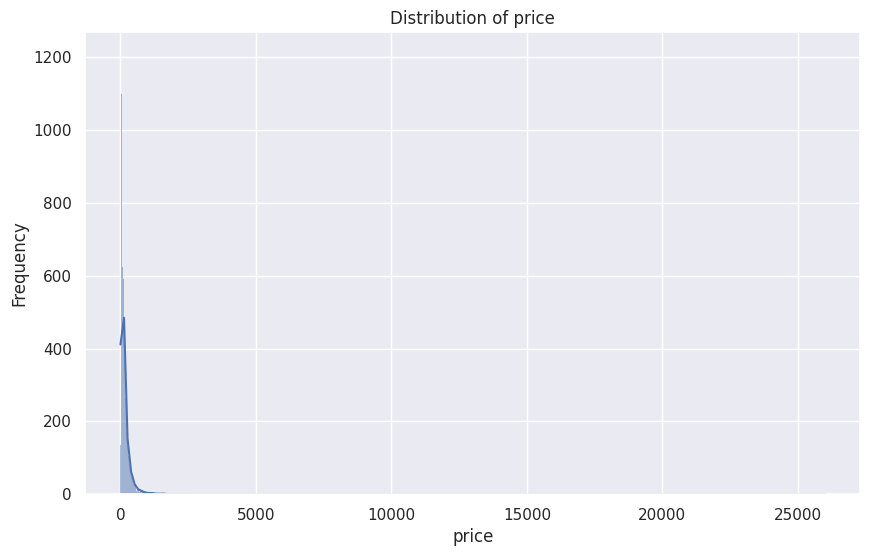

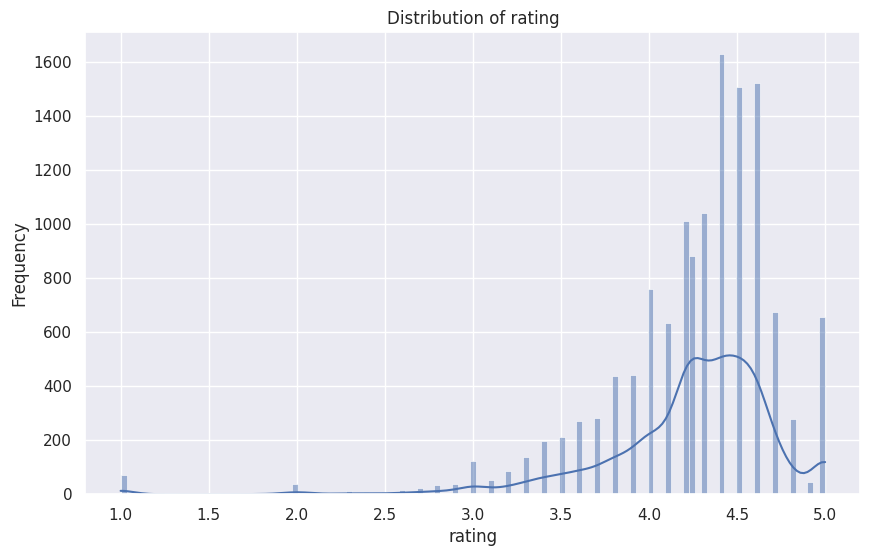

In [ ]:
# Get a list of numerical columns
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()

# Iterate through numerical columns and create histograms
for col in numerical_cols:
    plt.figure(figsize=(10, 6))
    sns.histplot(data=df, x=col, kde=True)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()

# Get a list of categorical columns
categorical_cols = df.select_dtypes(include='object').columns.tolist()

# Iterate through categorical columns and create countplots
for col in categorical_cols:
    plt.figure(figsize=(10, 6))
    sns.countplot(data=df, x=col)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

# We can also use value_counts for a quick look at categorical data distribution
for col in categorical_cols:
    print(f"Value counts for {col}:\n{df[col].value_counts()}\n")

In [ ]:
# Numerical-Numerical relationships (Scatter plots)
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()

# Iterate through pairs of numerical columns and create scatter plots
for i in range(len(numerical_cols)):
    for j in range(i + 1, len(numerical_cols)):
        col1 = numerical_cols[i]
        col2 = numerical_cols[j]
        plt.figure(figsize=(10, 6))
        sns.scatterplot(data=df, x=col1, y=col2)
        plt.title(f'Scatter plot of {col1} vs {col2}')
        plt.xlabel(col1)
        plt.ylabel(col2)
        plt.show()

# Categorical-Numerical relationships (Box plots)
categorical_cols = df.select_dtypes(include='object').columns.tolist()
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()

# Iterate through categorical and numerical columns and create box plots
for cat_col in categorical_cols:
    for num_col in numerical_cols:
        plt.figure(figsize=(10, 6))
        sns.boxplot(data=df, x=cat_col, y=num_col)
        plt.title(f'Box plot of {num_col} by {cat_col}')
        plt.xlabel(cat_col)
        plt.ylabel(num_col)
        plt.xticks(rotation=45, ha='right')
        plt.tight_layout()
        plt.show()

In [ ]:
plt.figure(figsize=(15, 8))
sns.heatmap(df.corr(numeric_only = True), annot=True, cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Matrix", fontsize=14)
plt.show()

# Thank you